# Benchmark: Simulated Annealing vs Branch & Bound

The aim is to check whether B&B scales better than SA for finding optimal solutions on KnapsackVolumetric instances.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time
import random
import json
import os

from Problem.KnapsackVolumetric import KnapsackVolumetric
from Problem.Converter import knapsack_to_qubo
from Algorithm.Classical_Algorithm.Branch_and_bound import BranchAndBound
from Algorithm.Classical_Algorithm.Simulated_annealing import simulated_annealing
from Algorithm.Classical_Algorithm.Exhaustive_search import exhaustive_search

## Generate KnapsackVolumetric instances of varying sizes

In [2]:
def generate_knapsack_instance(n, seed=0):
    """Generate a random KnapsackVolumetric instance of size n."""
    np.random.seed(seed)
    prices = [int(x) for x in np.random.randint(1, 50, size=n)]
    weights = [int(x) for x in np.random.randint(1, 20, size=n)]
    volumes = [int(x) for x in np.random.randint(1, 15, size=n)]
    # Set capacity to about 40% of total to make it challenging
    capacity = int(0.4 * sum(weights)) + 1
    max_volume = int(0.4 * sum(volumes)) + 1
    return KnapsackVolumetric(prices, weights, capacity, volumes, max_volume)

sizes = [10, 15, 20, 25]
n_instances_per_size = 5

instances = {}
for size in sizes:
    instances[size] = []
    for i in range(n_instances_per_size):
        inst = generate_knapsack_instance(size, seed=size*100 + i)
        instances[size].append(inst)
    print(f"Size {size}: {n_instances_per_size} instances created")

Size 10: 5 instances created
Size 15: 5 instances created
Size 20: 5 instances created
Size 25: 5 instances created


## Save instances to files

In [3]:
os.makedirs('instances', exist_ok=True)

for size in sizes:
    for i, inst in enumerate(instances[size]):
        data = {
            'prices': inst.prices,
            'weights': inst.weights,
            'volumes': inst.volumes,
            'capacity': inst.capacity,
            'max_volume': inst.max_volume
        }
        filename = f'instances/knapsack_n{size}_instance{i}.json'
        with open(filename, 'w') as f:
            json.dump(data, f)

print("All instances saved.")

All instances saved.


## Compare B&B vs Exhaustive Search

In [4]:
bb_times = {}
exhaustive_times = {}

for size in sizes:
    bb_times[size] = []
    exhaustive_times[size] = []
    for inst in instances[size]:
        # B&B
        start = time.time()
        bb = BranchAndBound(inst)
        sol_bb, val_bb = bb.solve()
        time_bb = time.time() - start
        bb_times[size].append(time_bb)
        
        # Exhaustive (skip if too large, takes too long)
        if size <= 20:
            start = time.time()
            sol_ex, val_ex = exhaustive_search(inst, maximize=True)
            time_ex = time.time() - start
            exhaustive_times[size].append(time_ex)
        else:
            exhaustive_times[size].append(float('nan'))
    
    print(f"Size {size}: B&B avg={np.mean(bb_times[size]):.4f}s, Exhaustive avg={np.nanmean(exhaustive_times[size]):.4f}s")

Size 10: B&B avg=0.0000s, Exhaustive avg=0.0007s


Size 15: B&B avg=0.0000s, Exhaustive avg=0.0383s


Size 20: B&B avg=0.0001s, Exhaustive avg=1.3150s
Size 25: B&B avg=0.0001s, Exhaustive avg=nans


C:\Users\Thomas\AppData\Local\Temp\ipykernel_27244\1407363820.py:24: RuntimeWarning: Mean of empty slice
  print(f"Size {size}: B&B avg={np.mean(bb_times[size]):.4f}s, Exhaustive avg={np.nanmean(exhaustive_times[size]):.4f}s")


C:\Users\Thomas\AppData\Local\Temp\ipykernel_27244\1771109675.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([bb_times[s] for s in sizes], labels=[str(s) for s in sizes])


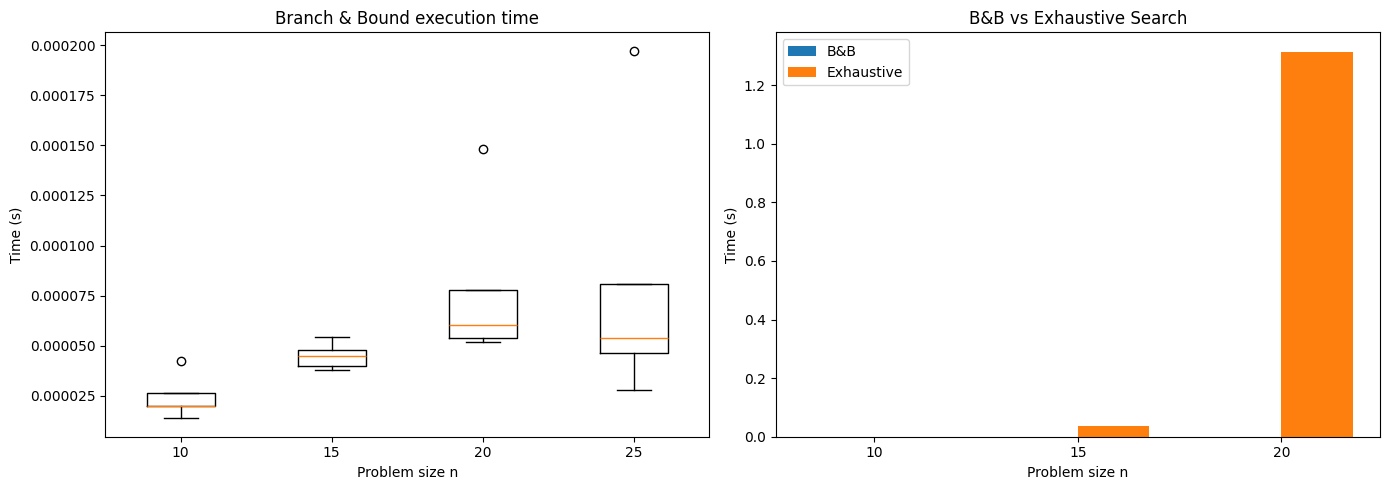

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# B&B time boxplot
axes[0].boxplot([bb_times[s] for s in sizes], labels=[str(s) for s in sizes])
axes[0].set_xlabel('Problem size n')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Branch & Bound execution time')

# B&B vs Exhaustive
small_sizes = [s for s in sizes if s <= 20]
x = np.arange(len(small_sizes))
width = 0.35
axes[1].bar(x - width/2, [np.mean(bb_times[s]) for s in small_sizes], width, label='B&B')
axes[1].bar(x + width/2, [np.nanmean(exhaustive_times[s]) for s in small_sizes], width, label='Exhaustive')
axes[1].set_xlabel('Problem size n')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('B&B vs Exhaustive Search')
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(s) for s in small_sizes])
axes[1].legend()

plt.tight_layout()
plt.show()

## Run SA on the same instances

In [6]:
sa_results = {}
sa_times_dict = {}

for size in sizes:
    sa_results[size] = []
    sa_times_dict[size] = []
    
    for idx, inst in enumerate(instances[size]):
        # Convert to QUBO
        qubo = knapsack_to_qubo(inst)
        
        steps = max(10, int(size * 2))
        
        start = time.time()
        best_sa, cost_sa = simulated_annealing(qubo, initial_temperature=100.0,
                                               decreasing_factor=0.95,
                                               steps_per_temp=steps,
                                               temp_threshold=0.01)
        time_sa = time.time() - start
        
        # Compare with B&B optimal
        bb = BranchAndBound(inst)
        sol_bb, val_bb = bb.solve()
        
        sa_knapsack_val = inst.eval(best_sa)
        
        sa_results[size].append({
            'sa_value': sa_knapsack_val,
            'bb_value': val_bb,
            'optimal_found': sa_knapsack_val == val_bb
        })
        sa_times_dict[size].append(time_sa)
    
    n_optimal = sum(1 for r in sa_results[size] if r['optimal_found'])
    print(f"Size {size}: SA found optimal in {n_optimal}/{n_instances_per_size} instances")

Size 10: SA found optimal in 0/5 instances
Size 15: SA found optimal in 0/5 instances


Size 20: SA found optimal in 0/5 instances


Size 25: SA found optimal in 0/5 instances


In [7]:
# Save results
os.makedirs('results', exist_ok=True)

results_data = {
    'sizes': sizes,
    'bb_times': {str(k): v for k, v in bb_times.items()},
    'sa_times': {str(k): v for k, v in sa_times_dict.items()},
}

with open('results/benchmark_results.json', 'w') as f:
    json.dump(results_data, f, default=str)

print("Results saved.")

Results saved.


## Conclusions

1. **B&B vs Exhaustive**: Branch & Bound is significantly faster thanks to pruning. The speedup increases with problem size.

2. **B&B scaling**: Still exponential in the worst case, but pruning helps a lot in practice.

3. **SA on Knapsack**: SA doesn't always find the optimal because:
   - The QUBO conversion adds penalty terms that change the landscape
   - SA is a heuristic and doesn't guarantee optimality
   - The penalty parameter needs careful tuning

4. **SA vs B&B**: For **optimal** solutions, B&B wins because it guarantees optimality. SA is useful for very large instances where B&B takes too long, but it may not converge to the optimal in the same time budget. The SA algorithm does not always have enough time to converge because the penalty-based QUBO formulation makes the energy landscape harder to navigate.